In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
     if (path / "scripts").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find the repository scripts directory.")

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

V3LE_FIG_ROOT = Path("/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/v3LE_paper")
FIG_DIR_ROOT = V3LE_FIG_ROOT / "budget"

In [47]:
from __future__ import annotations

import os
import glob
import re
import json
import time
import datetime
from typing import Dict, Tuple, Optional
from global_land_mask import globe

import xarray as xr

import unicodedata
import pprint 
import shutil

from typing import Optional

try:
    # xCDAT for CF bounds utilities and lon handling
    from xcdat import open_dataset as xcdat_open
    _HAVE_XCDAT = True
except Exception:
    xcdat_open = xr.open_dataset
    _HAVE_XCDAT = False

try:
    import xskillscore as xs
    _HAVE_XS = True
except Exception:
    _HAVE_XS = False

# optional: MetPy smoothing (safe fallback if not installed)
try:
    from metpy.calc import smooth_n_point as _smooth_n_point
    _HAS_METPY = True
except Exception:
    _HAS_METPY = False
    def _smooth_n_point(arr, n=9, passes=2):
        return arr  # no-op fallback
    
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as matcolors
import matplotlib.path as matpath
import matplotlib.ticker as mticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from collections.abc import Mapping

from matplotlib.cm import ScalarMappable
from matplotlib.offsetbox import AnchoredText

# Local imports
from exp_info import Budget_CATALOG, RUN_CATALOG, REGION_CATALOG, VARIABLE_CATALOG


In [48]:
class ExpDataReader:
    def __init__(
        self,
        data_dir: str,
        regnam: str,
        dtype: str,
        *,
        run_catalog: Optional[Dict[str, Dict[str, str]]] = None,
        region_catalog: Optional[Dict[str, Tuple[Tuple[float, float], Tuple[float, float]]]] = None,
        sfc_mask_ref: str = "MODIS.observation",
        sfc_mask_var: str = "TS",
        sfc_mask_kind: str = "land",
        debug_key: Optional[str] = None,
        verbose: bool = False,
    ):
        self.data_dir = os.path.abspath(data_dir)
        self.regnam = regnam
        self.dtype = dtype
        self.sfc_mask_ref = sfc_mask_ref
        
        # copy to avoid accidental mutation of module-level defaults
        self.run_catalog = dict(RUN_CATALOG) if run_catalog is None else dict(run_catalog)
        self.region_catalog = dict(REGION_CATALOG) if region_catalog is None else dict(region_catalog)

        if self.sfc_mask_ref not in self.run_catalog:
            raise KeyError(f"sfc_mask_ref='{self.sfc_mask_ref}' not found in run_catalog")

        self.sfc_mask_var = sfc_mask_var
        self.sfc_mask_kind = sfc_mask_kind
        self.debug_key = debug_key
        self.verbose = verbose

        # region bounds (store both slices and raw bounds)
        (lat_min, lat_max), (lon_min, lon_max) = self._region_bounds(self.regnam)
        lon_min, lon_max = self._normalize_region_lon_bounds(lon_min, lon_max)
        self.lat_slice = slice(lat_min, lat_max)
        self.lon_slice = slice(lon_min, lon_max)
        self.lat_bounds = (lat_min, lat_max)
        self.lon_bounds = (lon_min, lon_max)

        self.exp_dict: Dict[str, xr.Dataset] = {}
        self.sfc_mask: Optional[xr.DataArray] = None

    def _meta_field(self, meta, field: str):
        """Return run metadata field from object or dict."""
        if hasattr(meta, field):
            return getattr(meta, field)
        if isinstance(meta, dict) and field in meta:
            return meta[field]
        raise KeyError(f"Run meta missing '{field}': {field} not found in {meta!r}")

    def gen_region_mask(self, data_dir, exp, dtype, period, var, regnam, debug=False):
        """
        Build a region-aware mask aligned to the reference grid.
        - base mask: finite data in `var` (1 where finite, 0 where NaN)
        - optional land/ocean filter via global_land_mask (if self.sfc_mask_kind in {'land','ocean'})
        - cropped to the region `regnam`
        Returns: xr.DataArray int8 with dims ('lat','lon') named 'region_mask'
        """
        # --- open & normalize lon ---
        refpath = os.path.join(data_dir, f"{exp}.{dtype}.{period}.nc")
        refds = xcdat_open(refpath, decode_times=True)

        lon_name = "lon" if "lon" in refds.coords else ("longitude" if "longitude" in refds.coords else None)
        if lon_name is None:
            raise ValueError("No longitude coordinate found ('lon' or 'longitude').")

        lons = refds[lon_name]
        # wrap 0–360 → −180..180 and sort
        if float(lons.min()) > -1.0 or float(lons.max()) > 180.0:
            new_lons = ((lons + 180) % 360) - 180
            refds = refds.assign_coords({lon_name: new_lons})
        refds = refds.sortby(lon_name)
        if lon_name == "longitude":
            refds = refds.rename({"longitude": "lon"})

        # ensure bounds (optional)
        refds = refds.bounds.add_missing_bounds()

        rlats = refds["lat"].values
        rlons = refds["lon"].values

        # --- get a 2D slice of var for base valid-data mask ---
        src = refds[var]
        drop_dims = [d for d in src.dims if d not in ("lat", "lon")]
        src2d = src.isel({d: 0 for d in drop_dims}).squeeze() if drop_dims else src.squeeze()

        # base mask: 1 where data finite, else 0
        base = xr.where(xr.apply_ufunc(np.isfinite, src2d), 1, 0).astype(np.int8).rename("region_mask")

        if debug:
            tot = int(base.size); val = int((base > 0).sum())
            print(f"[mask-base] finite cells={val}/{tot} ({val/tot:.1%})")

        # --- optional land/ocean filter ---
        kind = getattr(self, "sfc_mask_kind", None)
        if kind in {"land", "ocean"}:
            try:
                from global_land_mask import globe
            except Exception as e:
                raise ImportError("Please `pip install global-land-mask` to use land/ocean masking.") from e

            lon_grid, lat_grid = np.meshgrid(rlons, rlats)
            reg_bool = globe.is_land(lat_grid, lon_grid) if kind == "land" else globe.is_ocean(lat_grid, lon_grid)
            reg_mask = xr.DataArray(reg_bool, coords={"lat": rlats, "lon": rlons}, dims=("lat", "lon"))
            base = xr.where(reg_mask, base, 0).astype(np.int8)

            if debug:
                val2 = int((base > 0).sum()); tot2 = int(base.size)
                print(f"[mask-{kind}] kept cells={val2}/{tot2} ({val2/tot2:.1%})")

        # --- ensure latitude ascending for consistent slicing ---
        if np.diff(base["lat"].values).mean() < 0:
            base = base.sortby("lat")

        # --- crop to region ---
        (lat_min, lat_max), (lon_min, lon_max) = self._region_bounds(regnam)
        lon_min, lon_max = self._normalize_region_lon_bounds(lon_min, lon_max)

        out = base.sel(lat=slice(lat_min, lat_max))

        if lon_min <= lon_max:
            out = out.sel(lon=slice(lon_min, lon_max))
        else:
            left  = out.sel(lon=slice(lon_min, 180))
            right = out.sel(lon=slice(-180, lon_max))
            out = xr.concat([left, right], dim="lon").sortby("lon")

        out = out.astype(np.int8).rename("region_mask")
        out.attrs.update({
            "region": regnam,
            "lon_bounds": (lon_min, lon_max),
            "lat_bounds": (lat_min, lat_max),
            "kind": getattr(self, "sfc_mask_kind", "any"),
        })

        if debug:
            totR = int(out.size); valR = int((out > 0).sum())
            print(f"[crop-{regnam}] kept cells={valR}/{totR} ({valR/totR:.1%}); "
                  f"extent=[{lon_min:.1f},{lon_max:.1f}]×[{lat_min:.1f},{lat_max:.1f}]")

        return out

    def _region_bounds(self, regnam: str):
        """Return ((lat_min, lat_max), (lon_min, lon_max)) from Region object/dict/tuple."""
        try:
            region = self.region_catalog[regnam]
        except KeyError:
            raise ValueError(f"Region '{regnam}' not found. Available: {list(self.region_catalog)}")

        # Region dataclass / object
        if hasattr(region, "lat_range") and hasattr(region, "lon_range"):
            (lat_min, lat_max) = region.lat_range
            (lon_min, lon_max) = region.lon_range
            return (float(lat_min), float(lat_max)), (float(lon_min), float(lon_max))

        # Dict style
        if isinstance(region, dict) and "lat_range" in region and "lon_range" in region:
            (lat_min, lat_max) = region["lat_range"]
            (lon_min, lon_max) = region["lon_range"]
            return (float(lat_min), float(lat_max)), (float(lon_min), float(lon_max))

        # Tuple/list style
        try:
            (lat_min, lat_max), (lon_min, lon_max) = region
            return (float(lat_min), float(lat_max)), (float(lon_min), float(lon_max))
        except Exception:
            raise TypeError(
                "REGION_CATALOG entry must be a Region with lat_range/lon_range, "
                "a dict with those keys, or ((lat_min,lat_max),(lon_min,lon_max))."
            )
        
    # --- longitude handling ---
    @staticmethod
    def _is_0_360(lons) -> bool:
        """
        Detect if longitude grid is in [0, 360).
        Works even for shifted grids like 0.5–359.5.
        """
        a = np.asarray(lons)
        minlon, maxlon = np.nanmin(a), np.nanmax(a)
        if minlon >= 0.0 and maxlon <= 360.0:
            return True
        if (0.0 <= minlon < 1.0) and (359.0 < maxlon <= 360.0):
            return True
        return False

    @staticmethod
    def _wrap_to_180(lon_vals):
        lon_vals = (lon_vals + 180.0) % 360.0 - 180.0
        return lon_vals

    def _normalize_longitude(self, ds: xr.Dataset) -> xr.Dataset:
        """Ensure ds.lon is in [-180, 180] and sorted ascending."""
        lon_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
        if lon_name is None:
            return ds  # nothing to do

        lons = ds[lon_name].values
        if self._is_0_360(lons):
            lons = self._wrap_to_180(lons)
            ds = ds.assign_coords({lon_name: lons})
        # always sort by lon
        ds = ds.sortby(lon_name)

        # For consistency rename to 'lon' if it's 'longitude'
        if lon_name == "longitude":
            ds = ds.rename({lon_name: "lon"})
        return ds

    @staticmethod
    def _normalize_region_lon_bounds(lon_min: float, lon_max: float):
        """Ensure region bounds use the [-180, 180] convention."""
        if -180.0 <= lon_min <= 180.0 and -180.0 <= lon_max <= 180.0:
            return lon_min, lon_max
        lon_min = (lon_min + 180.0) % 360.0 - 180.0
        lon_max = (lon_max + 180.0) % 360.0 - 180.0
        return lon_min, lon_max

    def _select_region_and_bounds(self, ds: xr.Dataset) -> xr.Dataset:
        """Subset by lat and lon, handling descending lat and dateline crossing."""
        ds = self._maybe_add_bounds(ds)

        # latitude
        if "lat" in ds.coords:
            lat_min, lat_max = self.lat_bounds
            lat_vals = ds["lat"].values
            lat_asc = bool(np.diff(lat_vals).mean() > 0)
            lat_slice = slice(lat_min, lat_max) if lat_asc else slice(lat_max, lat_min)
            ds = ds.sel(lat=lat_slice)

        # longitude
        if "lon" not in ds.coords:
            return ds

        lon_min, lon_max = self.lon_bounds
        if lon_min <= lon_max:
            return ds.sel(lon=slice(lon_min, lon_max))
        else:
            # crosses dateline
            left  = ds.sel(lon=slice(lon_min, 180))
            right = ds.sel(lon=slice(-180, lon_max))
            right = right.assign_coords(lon=self._wrap_to_180(right["lon"]))
            return xr.concat([left, right], dim="lon").sortby("lon")

    def _maybe_add_bounds(self, ds: xr.Dataset) -> xr.Dataset:
        if _HAVE_XCDAT:
            try:
                ds = ds.bounds.add_missing_bounds()
            except Exception:
                pass
        return ds

    def _sync_time_to_reference(self):
        ref_time = self.exp_dict[self.sfc_mask_ref]["time"]
        for k in list(self.exp_dict.keys()):
            if k != self.sfc_mask_ref and "time" in self.exp_dict[k].coords:
                self.exp_dict[k] = self.exp_dict[k].assign_coords(time=ref_time)

    def _debug_print(self, key, path, lats0=None, lons0=None):
        if key != self.debug_key:
            return
        print(f"[DEBUG] {key}")
        if lats0 is not None:
            print("  lats0:", np.asarray(lats0).min(), "→", np.asarray(lats0).max())
        if lons0 is not None:
            print("  lons0:", np.asarray(lons0).min(), "→", np.asarray(lons0).max())
        print("  period:", self.run_catalog[key]["period"])
        print("  path:", path)
        print("  lon(post):", self.exp_dict[key]["lon"].min().item(), "→", self.exp_dict[key]["lon"].max().item())

    def _normalize_period_str(self, s: str) -> str:
        _DASHES = {
            "\u2010": "-",  # hyphen
            "\u2011": "-",  # non-breaking hyphen
            "\u2012": "-",  # figure dash
            "\u2013": "-",  # en dash
            "\u2014": "-",  # em dash
            "\u2212": "-",  # minus sign
        }
        s = unicodedata.normalize("NFKC", s)
        return s.translate(str.maketrans(_DASHES)).strip()
    
    # --- main API ---
    def read(self, debug=False):
        for exp_key, meta in self.run_catalog.items():
            raw_period = self._meta_field(meta, "period")
            period = self._normalize_period_str(raw_period)
            nc_path = os.path.join(self.data_dir, f"{exp_key}.{self.dtype}.{period}.nc")
            if self.verbose:
                print(f"Loading: {nc_path}")
            if not os.path.exists(nc_path):
                raise FileNotFoundError(f"File not found for run '{exp_key}': {nc_path}")

            ds = xcdat_open(nc_path, decode_times=True)

            # pick a reasonable debug variable
            dbg_var = "TS" if "TS" in ds.data_vars else ("FLNS" if "FLNS" in ds.data_vars else None)
            if debug and dbg_var:
                da0 = ds[dbg_var]
                tot0   = int(da0.size)
                valid0 = int(da0.notnull().sum())
                lon_name = "lon" if "lon" in ds.coords else ("longitude" if "longitude" in ds.coords else None)
                if lon_name:
                    print(f"[open] {exp_key}: valid={valid0}/{tot0} ({valid0/tot0:.1%}); "
                          f"lon-range={float(ds[lon_name].min()):.2f}..{float(ds[lon_name].max()):.2f}")
                else:
                    print(f"[open] {exp_key}: valid={valid0}/{tot0} ({valid0/tot0:.1%}); no lon")

            # lon normalize
            ds = self._normalize_longitude(ds)
            if debug and dbg_var:
                daN = ds[dbg_var]
                totN   = int(daN.size)
                validN = int(daN.notnull().sum())
                print(f"[norm] {exp_key}: valid={validN}/{totN} ({validN/totN:.1%}); "
                      f"lon-range={float(ds['lon'].min()):.2f}..{float(ds['lon'].max()):.2f}")

            # region crop (handles descending lat and dateline)
            ds = self._select_region_and_bounds(ds)
            if debug and dbg_var:
                daR = ds[dbg_var]
                totR   = int(daR.size)
                validR = int(daR.notnull().sum())
                print(f"[crop] {exp_key}: valid={validR}/{totR} ({validR/totR:.1%}); "
                      f"extent={self.lon_bounds}×{self.lat_bounds}")

            self.exp_dict[exp_key] = ds
            if debug:
                lats0 = ds["lat"].values if "lat" in ds.coords else None
                lons0 = ds["lon"].values if "lon" in ds.coords else None
                self._debug_print(exp_key, nc_path, lats0, lons0)

        if self.sfc_mask_ref not in self.exp_dict:
            raise KeyError(f"Reference '{self.sfc_mask_ref}' not loaded (after reading).")

        # Align time to reference
        self._sync_time_to_reference()

        # Build land mask using the reference run's period
        ref_meta = self.run_catalog[self.sfc_mask_ref]
        ref_period_raw = self._meta_field(ref_meta, "period")
        ref_period = self._normalize_period_str(ref_period_raw)

        # generate region/land mask consistent with reference
        self.sfc_mask = self.gen_region_mask(
            self.data_dir, self.sfc_mask_ref, self.dtype, ref_period,
            self.sfc_mask_var, self.regnam, debug=debug
        )
        return self.run_catalog, self.exp_dict, self.sfc_mask


In [51]:
class GridBugetAnalysis:
    """
    Zonal (lon-avg) energy-budget Hovmöller (lat × month).

    Key separation:
      - budget_vars: list of budget fields to compute & plot (e.g., ['TS_ALL','TS_TURB',...])
      - term_specs: optional per-term plotting specs {term: {'unit','min','max','nlev'}, ...}

    Output filename matches your driver:
      fig_zonalbudget_{plot_type}_{refexp}_{var}_{regnam}_{period}.pdf
    """

    def __init__(
        self,
        run_dict,
        df,
        lmsk,
        months,
        regnam,
        model_list,
        *,
        budget_vars=None,        # <- list[str] of budget terms to compute/plot
        term_specs=None,         # <- optional per-term specs overriding var_dict
        plot_type="model_vs_obs",
        budget_type="best_obs",
        region_bounds=None,      # ((lat_min,lat_max),(lon_min,lon_max)) or None
        fgw=35,
        fgh=12,
        hs=0.5,
        ws=0.5,
        region_catalog=None,     # unused, kept for API compatibility
        debug=False,
        budget_fn=None,          # optional external override for budget derivation
    ):
        self.run_dict = run_dict
        self.df = df
        self.lmsk = lmsk
        self.term_specs = term_specs or {}
        self.months = list(months)
        self.regnam = regnam
        self.model_list = list(model_list)
        self.plot_type = plot_type
        self.budget_type = budget_type
        self.region_bounds = region_bounds
        self.fgw = float(fgw)
        self.fgh = float(fgh)
        self.hs = float(hs)
        self.ws = float(ws)
        self.region_catalog = region_catalog or {}
        self.debug = bool(debug)
        self.budget_fn = budget_fn

        # Which terms to plot?
        if budget_vars is not None and len(budget_vars) > 0:
            self.plot_terms = list(budget_vars)
        else:
            # fallback: if user passed a dict of terms directly as term_specs
            self.plot_terms = list(self.term_specs.keys()) if self.term_specs else ["TS_ALL"]

        # region ranges
        self.lat_range = (-90.0, 90.0)
        self.lon_range = (-180.0, 180.0)
        if isinstance(region_bounds, (list, tuple)) and len(region_bounds) == 2:
            self.lat_range, self.lon_range = region_bounds

    # ---------- helpers ----------
    @staticmethod
    def _generate_coslat_weight(da):
        lat = da["lat"] if "lat" in da.coords else da
        return xr.DataArray(np.cos(np.deg2rad(lat)), dims=["lat"], coords={"lat": lat})

    @staticmethod
    def _meta_get(meta, key, default=None):
        if isinstance(meta, Mapping):
            return meta.get(key, default)
        return getattr(meta, key, default)

    @staticmethod
    def _restrict_lonlat(da, lat_range, lon_range):
        if "lon" in da.coords:
            lon = da["lon"]
            if float(lon.max()) > 180.0:
                new_lon = ((lon + 180.0) % 360.0) - 180.0
                da = da.assign_coords(lon=new_lon).sortby("lon")
        lat0, lat1 = lat_range
        lon0, lon1 = lon_range
        if "lat" in da.coords:
            da = da.sel(lat=slice(lat0, lat1))
        if "lon" in da.coords:
            if lon0 <= lon1:
                da = da.sel(lon=slice(lon0, lon1))
            else:
                da = xr.concat(
                    [da.sel(lon=slice(lon0, 180)), da.sel(lon=slice(-180, lon1))],
                    dim="lon",
                )
        return da

    @staticmethod
    def _to_mask_like(lmsk, like_da: xr.DataArray) -> xr.DataArray:
        if isinstance(lmsk, xr.Dataset):
            for key in ("mask", "landmask", "sftlf"):
                if key in lmsk:
                    lmsk = lmsk[key]
                    break
            else:
                raise ValueError("Mask Dataset provided but no ['mask','landmask','sftlf'] var found.")
        if isinstance(lmsk, xr.DataArray):
            m = lmsk
            if "lat" in like_da.coords and "lat" in m.coords:
                m = m.sel(lat=like_da.lat, method="nearest")
            if "lon" in like_da.coords and "lon" in m.coords:
                m = m.sel(lon=like_da.lon, method="nearest")
            m = m.astype("float64")
        else:
            m = xr.DataArray(
                np.asarray(lmsk),
                dims=["lat", "lon"],
                coords={"lat": like_da.lat, "lon": like_da.lon},
            ).astype("float64")
        return xr.where(m > 0.5, 1.0, 0.0)

    @staticmethod
    def _month_labels_shifted(months, regnam):
        idx_shift = 4 if regnam in ["Antarctic"] else 1
        months = list(months)
        if len(months) == 12:
            return months[-idx_shift:] + months[:-idx_shift], idx_shift
        return months, 0

    @staticmethod
    def _xyticks_for_region(regnam):
        if regnam == "Antarctic":
            return ([-90, -80, -70, -60, -50], ["90°S", "80°S", "70°S", "60°S", "50°S"])
        elif regnam in ("PolarN", "Greenland"):
            return ([50, 60, 70, 80, 90], ["50°N", "60°N", "70°N", "80°N", "90°N"])
        elif regnam == "Atlantic":
            return ([0, 10, 30, 50, 70], ["0°", "10°N", "30°N", "50°N", "70°N"])
        elif regnam == "CONUS":
            return ([-5, 10, 25, 40, 55], ["5°S", "10°N", "25°N", "40°N", "55°N"])
        else:
            return ([-90, -45, 0, 45, 90], ["90°S", "45°S", "0°", "45°N", "90°N"])

    @staticmethod
    def _budget_cmap():
        color_list4 = ["darkblue", "lightblue", "white", "lightyellow", "orange", "firebrick"]
        nodes = [0.0, 0.3, 0.5, 0.5, 0.8, 1.0]
        return matcolors.LinearSegmentedColormap.from_list("mybluewhitered", list(zip(nodes, color_list4)))

    # ---------- internal budget derivation (uses self.plot_terms) ----------
    @staticmethod
    def _ensure_kelvin(ts):
        try:
            mx = float(ts.max().values)
        except Exception:
            mx = np.nan
        return ts + 273.15 if (np.isfinite(mx) and mx < 150.0) else ts

    @staticmethod
    def _align(*das):
        out = xr.align(*das, join="inner")
        return tuple(a.astype("float64") for a in out)

    def _diag(self, model: str, name: str, da: xr.DataArray):
        """Print nan-safe min/max/mean (+valid count). Handles dask laziness."""
        v = da
        try:
            # compute if dask-backed
            if hasattr(v.data, "compute"):
                v = v.compute()
        except Exception:
            pass
        arr = v.values  # numpy array
        vmin = np.nanmin(arr)
        vmax = np.nanmax(arr)
        vmean = np.nanmean(arr)
        nvalid = np.isfinite(arr).sum()
        print(f"[diag] {model:>18s} {name:8s} | min={vmin: .3f}, max={vmax: .3f}, mean={vmean: .3f}, nvalid={nvalid}")

    def _has(self, ds: xr.Dataset, name: str) -> bool:
        try:
            return name in ds
        except Exception:
            return False

    def _pick(self, ds: xr.Dataset, *names: str) -> xr.DataArray:
        for nm in names:
            if self._has(ds, nm):
                return ds[nm]
        raise KeyError(f"None of {names} found in dataset.")

    def _derive_energy_budget_internal(self):
        # choose reference datasets
        if self.budget_type == "all_merra":
            refts = reftur = refrad = "MERRA2.analysis"
        elif self.budget_type == "best_obs":
            refts = "HadISST.analysis"
            refrad = "CERES_EBAF.observation"
            reftur = "MERRA2.analysis"
        else:
            raise ValueError(f"Unknown budget_type: {self.budget_type}")

        sigma = 5.67e-8
        ts_ref = self._ensure_kelvin(self.df[refts]["TS"])
        denom = 4.0 * sigma * (ts_ref ** 3)
        factor = 1.0 / xr.where(denom == 0.0, np.nan, denom)

        if self.debug:
            print(f"reference data: {refts}, {refrad}, {reftur}")

        # --- albedo reference (prefer direct ALBEDOC_SRF) ---
        #if self._has(self.df[refrad], "ALBEDOC_SRF"):
        #    albedom = self.df[refrad]["ALBEDOC_SRF"].astype("float64")
        #else:
        #    fsnsc = self._pick(self.df[refrad], "FSNSC").astype("float64")
        #    fsdsc = self._pick(self.df[refrad], "FSDSC").astype("float64")
        #    ratio = xr.where(fsdsc == 0.0, 0.0, fsnsc / fsdsc)
        #    albedom = (1.0 - ratio).clip(0.0, 1.0)
        
        # --- albedo reference (prefer direct ALBEDOC_SRF) ---            
        fsnsc = self._pick(self.df[refrad], "FSNSC").astype("float64")
        fsdsc = self._pick(self.df[refrad], "FSDSC").astype("float64")
        ratio = xr.where(fsdsc == 0.0, 0.0, fsnsc / fsdsc)
        albedom = (1.0 - ratio).clip(0.0, 1.0)
        
        budget_dict = {}
        for model in self.model_list:
            outds = self.df[model].copy()

            # compute everything except TS_Sum first
            sum_requested = ("TS_Sum" in self.plot_terms)

            for term in self.plot_terms:
                if term == "TS_Sum":
                    # defer until after components are computed
                    continue

                if term == "TS_ALL":
                    ts_r, ts_m = self._align(ts_ref, self._ensure_kelvin(self.df[model]["TS"]))
                    outds["TS_ALL"] = ts_m - ts_r
                    if self.debug: self._diag(model, "TS_ALL", outds["TS_ALL"])

                elif term == "TS_TURB":
                    sh, lh, shr, lhr = self._align(
                        self._pick(self.df[model], "SHFLX"),
                        self._pick(self.df[model], "LHFLX"),
                        self._pick(self.df[reftur], "SHFLX"),
                        self._pick(self.df[reftur], "LHFLX"),
                    )
                    outds["TS_TURB"] = (-(sh + lh) * factor) - (-(shr + lhr) * factor)
                    if self.debug: self._diag(model, "TS_TURB", outds["TS_TURB"])

                elif term == "TS_Qn":
                    fs, fl, sh, lh, fsr, flr, shr, lhr = self._align(
                        self._pick(self.df[model], "FSNS"),
                        self._pick(self.df[model], "FLNS"),
                        self._pick(self.df[model], "SHFLX"),
                        self._pick(self.df[model], "LHFLX"),
                        self._pick(self.df[refrad], "FSNS"),
                        self._pick(self.df[refrad], "FLNS"),
                        self._pick(self.df[reftur], "SHFLX"),
                        self._pick(self.df[reftur], "LHFLX"),
                    )
                    qn_mod = -fs + fl + sh + lh
                    qn_ref = -fsr + flr + shr + lhr
                    outds["TS_Qn"] = qn_mod * factor - qn_ref * factor
                    if self.debug: self._diag(model, "TS_Qn", outds["TS_Qn"])

                elif term == "TS_CRE":
                    swc, lwc, swcr, lwcr = self._align(
                        self._pick(self.df[model], "SWCF_SRF"),
                        self._pick(self.df[model], "LWCF_SRF"),
                        self._pick(self.df[refrad], "SWCF_SRF"),
                        self._pick(self.df[refrad], "LWCF_SRF"),
                    )
                    outds["TS_CRE"] = (swc + lwc) * factor - (swcr + lwcr) * factor
                    if self.debug: self._diag(model, "TS_CRE", outds["TS_CRE"])

                elif term == "TS_SAF":
                    #if self._has(self.df[model], "ALBEDOC_SRF"):
                    #    alb_m = self.df[model]["ALBEDOC_SRF"].astype("float64")
                    #else:
                    #    fsnsc_m = self._pick(self.df[model], "FSNSC").astype("float64")
                    #    fsdsc_m = self._pick(self.df[model], "FSDSC").astype("float64")
                    #    alb_m = (1.0 - xr.where(fsdsc_m == 0.0, 0.0, fsnsc_m / fsdsc_m)).clip(0.0, 1.0)
                    fsnsc_m = self._pick(self.df[model], "FSNSC").astype("float64")
                    fsdsc_m = self._pick(self.df[model], "FSDSC").astype("float64")
                    alb_m = (1.0 - xr.where(fsdsc_m == 0.0, 0.0, fsnsc_m / fsdsc_m)).clip(0.0, 1.0)  
                    alb_m, alb_r, fsdsc_r = self._align(alb_m, albedom, self._pick(self.df[refrad], "FSDSC"))
                    outds["TS_SAF"] = -(alb_m - alb_r) * fsdsc_r * factor
                    if self.debug: self._diag(model, "TS_SAF", outds["TS_SAF"])

                elif term == "TS_nSAF":
                    fsdsc_m, fsdsc_r, alb_r = self._align(
                        self._pick(self.df[model], "FSDSC"),
                        self._pick(self.df[refrad], "FSDSC"),
                        albedom,
                    )
                    outds["TS_nSAF"] = -(1.0 - alb_r) * fsdsc_m * factor + (1.0 - alb_r) * fsdsc_r * factor
                    if self.debug: self._diag(model, "TS_nSAF", outds["TS_nSAF"])

                elif term == "TS_DLW":
                    if self._has(self.df[refrad], "FLDSC"):
                        fldsc_r = self.df[refrad]["FLDSC"]
                    elif self._has(self.df[refrad], "FLDS"):
                        fldsc_r = self.df[refrad]["FLDS"]
                    else:
                        raise KeyError(f"No downward LW flux (FLDSC/FLDS) in {refrad}")
                    fldsc_m, fldsc_r = self._align(self._pick(self.df[model], "FLDSC"), fldsc_r)
                    outds["TS_DLW"] = fldsc_m * factor - fldsc_r * factor
                    if self.debug: self._diag(model, "TS_DLW", outds["TS_DLW"])

                else:
                    # If a raw field was requested, pass it through; otherwise error.
                    if self._has(self.df[model], term):
                        outds[term] = self.df[model][term]
                        if self.debug: self._diag(model, term, outds[term])
                    else:
                        raise KeyError(f"Requested term '{term}' is unknown and not present in the dataset.")

            # now, compute TS_Sum if requested
            if sum_requested:
                parts = [k for k in ["TS_TURB", "TS_Qn", "TS_CRE", "TS_SAF", "TS_nSAF", "TS_DLW"] if k in outds]
                if parts:
                    acc = outds[parts[0]]
                    for k in parts[1:]:
                        a, b = self._align(acc, outds[k])
                        acc = a + b
                    outds["TS_Sum"] = acc
                    if self.debug: self._diag(model, "TS_Sum", outds["TS_Sum"])

            budget_dict[model] = outds

        return budget_dict

    def _month_day_weights(self, da: xr.DataArray) -> xr.DataArray:
        """
        Return per-sample day weights aligned to da:
          - If 'time' dim: uses time.dt.days_in_month
          - If 'month' dim: uses canonical [31,28/29,31,...] (28 for Feb by default)
        Weights return shape matches da along the time-like dimension.
        """
        if "time" in da.dims:
            return da["time"].dt.days_in_month.astype("float64")
        if "month" in da.dims:
            # canonical clim day counts (Feb=28). Adjust to 29 if you prefer leap climatology.
            day_counts = np.array([31,28,31,30,31,30,31,31,30,31,30,31], dtype="float64")
            return xr.DataArray(day_counts, dims=["month"], coords={"month": np.arange(1,13)})
        raise ValueError("Expected a 'time' or 'month' dimension.")

    def _season_selector(self, da: xr.DataArray, season: str) -> xr.DataArray:
        """
        Subset da (which has 'time' or 'month') to the requested season.
        Seasons: 'ANN','DJF','MAM','JJA','SON'
        """
        season = season.upper()
        if season == "ANN":
            return da

        if "time" in da.dims:
            mon = da["time"].dt.month
            if season == "DJF":
                return da.where((mon==12)|(mon==1)|(mon==2), drop=True)
            if season == "MAM":
                return da.where((mon>=3)&(mon<=5), drop=True)
            if season == "JJA":
                return da.where((mon>=6)&(mon<=8), drop=True)
            if season == "SON":
                return da.where((mon>=9)&(mon<=11), drop=True)
        elif "month" in da.dims:
            if season == "DJF":
                return da.sel(month=[12,1,2])
            if season == "MAM":
                return da.sel(month=[3,4,5])
            if season == "JJA":
                return da.sel(month=[6,7,8])
            if season == "SON":
                return da.sel(month=[9,10,11])

        raise ValueError("Unknown season or missing time-like dimension.")

    def _weighted_zonal_mean_scalar(
        self, da: xr.DataArray, latmin: float = 40.0, latmax: float = 70.0
    ) -> xr.DataArray:
        """
        Cos(lat) × day-weighted mean of a zonal-mean field da with dims in {'time','month','lat'}.
        Optionally restricts to a latitude band [latmin, latmax].
        Returns a scalar xr.DataArray.
        """
        if "lat" not in da.dims:
            raise ValueError("Expected 'lat' dimension.")

        # restrict latitude band
        da = da.where((da["lat"] >= latmin) & (da["lat"] <= latmax), drop=True)

        # cos(lat) weights
        wlat = self._generate_coslat_weight(da["lat"])
        Wlat = xr.ones_like(da) * wlat

        # time/day weights
        if "time" in da.dims:
            wtime = self._month_day_weights(da)
            Wtime = xr.ones_like(da) * wtime
            W = Wlat * Wtime
            num = (da * W).sum(dim=("time","lat"), skipna=True)
            den = W.sum(dim=("time","lat"), skipna=True)
            return num / den

        if "month" in da.dims:
            wmon = self._month_day_weights(da)
            Wtime = xr.ones_like(da) * wmon
            W = Wlat * Wtime
            num = (da * W).sum(dim=("month","lat"), skipna=True)
            den = W.sum(dim=("month","lat"), skipna=True)
            return num / den

        # no time-like dimension → lat-weighted mean only
        num = (da * Wlat).sum(dim="lat", skipna=True)
        den = Wlat.sum(dim="lat", skipna=True)
        return num / den

    def _season_means(self, da: xr.DataArray) -> dict:
        out = {}
        for s in ("ANN","DJF","MAM","JJA","SON"):
            ssub = self._season_selector(da, s)
            out[s] = float(self._weighted_zonal_mean_scalar(ssub).values)
        return out

    def save_season_diagnostics_ascii(self, filename: str):
        """
        Save ANN + seasonal means to a plain ASCII file.
        """
        with open(filename, "w") as f:
            # header
            f.write("# Seasonal means (ANN, DJF, MAM, JJA, SON)\n")
            f.write("# Model   Variable   ANN   DJF   MAM   JJA   SON\n")

            for (model, var), seas in self._season_diag.items():
                ann  = seas.get("ANN", float("nan"))
                djf  = seas.get("DJF", float("nan"))
                mam  = seas.get("MAM", float("nan"))
                jja  = seas.get("JJA", float("nan"))
                son  = seas.get("SON", float("nan"))

                f.write(f"{model:20s} {var:10s} "
                        f"{ann:8.2f} {djf:8.2f} {mam:8.2f} {jja:8.2f} {son:8.2f}\n")

        print(f"[info] Saved seasonal diagnostics to {filename}")

    # ---------- main ----------
    def plot(self, fontz=10, show=False, return_fig=False, outdir=".", show_mean_str=False, filename=None):
        """
        One figure: rows=models, cols=terms.
        One colorbar per row (shared limits across that row).
        """
        # --- derive data
        budget_dict = (
            self.budget_fn(self.budget_type, self.model_list, {t: {} for t in self.plot_terms}, self.df)
            if callable(self.budget_fn)
            else self._derive_energy_budget_internal()
        )

        # --- grid dims
        nrows = len(self.model_list)
        ncols = len(self.plot_terms)

        # scale figure sensibly with grid size
        base_w_per_col = max(self.fgw / max(1.0, 5.0), 6.0)
        base_h_per_row = max(self.fgh / 1.0, 6.0)
        fig_w = base_w_per_col * ncols
        fig_h = base_h_per_row * nrows

        fig, axes = plt.subplots(
            nrows, ncols,
            figsize=(fig_w, fig_h),
            squeeze=False,
            sharex=True, sharey=True
        )

        xticks_all, xtlabels_all = self._xyticks_for_region(self.regnam)
        month_labels, roll_n = self._month_labels_shifted(self.months, self.regnam)
        cmap = self._budget_cmap()

        # optional sanity print
        if self.debug:
            print(f"[grid] models={nrows}, terms={ncols} -> single figure {nrows}x{ncols}")

        # --- precompute row-wise limits (shared across terms -> honest colorbar per row)
        row_limits = []
        for i, model in enumerate(self.model_list):
            row_vmin, row_vmax = np.inf, -np.inf
            # First pass: check specs; if not set, peek data to get robust percentiles
            for term in self.plot_terms:
                vinfo = self.term_specs.get(term, {})
                if isinstance(vinfo, dict):
                    vmin_spec = vinfo.get("min", None)
                    vmax_spec = vinfo.get("max", None)
                else:
                    vmin_spec = getattr(vinfo, "min", None)
                    vmax_spec = getattr(vinfo, "max", None)

                raw = budget_dict[model][term]
                raw = self._restrict_lonlat(raw, self.lat_range, self.lon_range)
                m = self._to_mask_like(self.lmsk, raw)
                vmod = raw.where(m > 0)
                mod_avg = vmod.mean("lon", skipna=True) if "lon" in vmod.dims else vmod

                tdim = "time" if "time" in mod_avg.dims else ("month" if "month" in mod_avg.dims else None)
                vplt = mod_avg
                if tdim and vplt.sizes.get(tdim, 0) == 12 and roll_n:
                    vplt = vplt.roll({tdim: roll_n})

                vals = vplt.values
                if vmin_spec is None or vmax_spec is None:
                    if np.isfinite(vals).any():
                        vmin_est = np.nanpercentile(vals, 2)
                        vmax_est = np.nanpercentile(vals, 98)
                    else:
                        vmin_est, vmax_est = -1.0, 1.0
                else:
                    vmin_est, vmax_est = vmin_spec, vmax_spec

                row_vmin = min(row_vmin, vmin_est)
                row_vmax = max(row_vmax, vmax_est)

            if not np.isfinite(row_vmin) or not np.isfinite(row_vmax) or row_vmin == row_vmax:
                row_vmin, row_vmax = -1.0, 1.0
            row_limits.append((row_vmin, row_vmax))

        # --- plot panels
        # keep last contour in each row to attach the row colorbar
        last_contour_in_row = [None] * nrows
        row_labels = [None] * nrows  # use the first term's alias/unit for label text

        for i, model in enumerate(self.model_list):
            rvmin, rvmax = row_limits[i]
            # pick a reasonable number of levels; prefer the first term's nlev if set
            first_vinfo = self.term_specs.get(self.plot_terms[0], {})
            if isinstance(first_vinfo, dict):
                nlev = first_vinfo.get("nlev", 11)
                vstr0 = first_vinfo.get("alias", self.plot_terms[0])
                vunt0 = first_vinfo.get("unit", "")
            else:
                nlev = getattr(first_vinfo, "nlev", 11)
                vstr0 = getattr(first_vinfo, "alias", self.plot_terms[0])
                vunt0 = getattr(first_vinfo, "unit", "")
            clevs_row = np.linspace(rvmin, rvmax, nlev)
            row_labels[i] = f"({vunt0})"

            for j, term in enumerate(self.plot_terms):
                ax = axes[i, j]

                # term specs (for labeling the panel tag)
                vinfo = self.term_specs.get(term, {})
                if isinstance(vinfo, dict):
                    vunt = vinfo.get("unit", "")
                    vstr = vinfo.get("alias", term)
                else:
                    vunt = getattr(vinfo, "unit", "")
                    vstr = getattr(vinfo, "alias", term)

                raw = budget_dict[model][term]
                raw = self._restrict_lonlat(raw, self.lat_range, self.lon_range)
                m = self._to_mask_like(self.lmsk, raw)
                vmod = raw.where(m > 0)
                mod_avg = vmod.mean("lon", skipna=True) if "lon" in vmod.dims else vmod

                # time handling
                tdim = "time" if "time" in mod_avg.dims else ("month" if "month" in mod_avg.dims else None)
                vplt = mod_avg
                if tdim and vplt.sizes.get(tdim, 0) == 12 and roll_n:
                    vplt = vplt.roll({tdim: roll_n})
                tsize = vplt.sizes.get(tdim, 0)
                ty = np.arange(1, tsize + 1) if tsize else np.arange(1, 12 + 1)

                # Compute ANN + seasonal means on the unrolled series (mod_avg)
                try:
                    seas = self._season_means(mod_avg)
                    # Keep concise on the panel; you can choose what to show:
                    # metrics_str = f"ANN:{seas['ANN']:.1f}  DJF:{seas['DJF']:.1f}  MAM:{seas['MAM']:.1f}  JJA:{seas['JJA']:.1f}  SON:{seas['SON']:.1f}"
                    # or shorter:
                    metrics_str = f"ANN:{seas['ANN']:.1f}  DJF:{seas['DJF']:.1f}"
                except Exception:
                    metrics_str = "ANN/DJF: n/a"

                ax.set_aspect(7.0, adjustable="box")

                if not np.isfinite(vplt.values).any():
                    ax.text(0.5, 0.5, "No valid data", transform=ax.transAxes,
                            ha="center", va="center", fontsize=fontz*0.95)
                    ax.set_ylabel(self._meta_get(self.run_dict[model], "name", str(model)), fontsize=fontz*0.95)
                    if i == 0:
                        ax.set_title(vstr, fontsize=fontz*1.0, pad=8)
                    if show_mean_str:
                        ax.set_title(metrics_str, loc="right", color="red", fontsize=fontz*0.95, pad=8, zorder=10)
                    continue

                zvals = _smooth_n_point(vplt.values, 9, 2) if _HAS_METPY else vplt.values

                cf = ax.contourf(
                    vplt["lat"].values,
                    ty,
                    zvals,
                    levels=clevs_row, vmin=rvmin, vmax=rvmax,
                    cmap=cmap, extend="both", zorder=0
                )
                cs = ax.contour(
                    vplt["lat"].values,
                    ty,
                    zvals, clevs_row, colors="k", linewidths=0.8
                )
                ax.clabel(cs, inline=True, fontsize=fontz*0.95, colors="cyan")

                # panel tag (alias + unit)
                tag = f"{metrics_str}" #f"{vstr}" if not vunt else f"{vstr}"
                ax.text(0.02, 0.96, tag, transform=ax.transAxes,
                        ha="left", va="top", fontsize=fontz, color="red",
                        bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.2", linewidth=0))

                last_contour_in_row[i] = cf  # for the row colorbar

                # ticks/labels
                xdata = vplt["lat"].values
                xticks = [x for x in xticks_all if x >= xdata.min() - 1e-9 and x <= xdata.max() + 1e-9]
                lbl_map = dict(zip(xticks_all, xtlabels_all))
                ax.set_xticks(xticks)
                ax.set_xticklabels([lbl_map[x] for x in xticks], fontsize=fontz*0.95)

                ax.set_yticks(ty)
                if tdim and tsize == 12:
                    ax.set_yticklabels(month_labels, fontsize=fontz*0.95)
                else:
                    ax.set_yticklabels(ty, fontsize=fontz*0.95)

                # titles & row labels
                if i == 0:
                    ax.set_title(vstr, fontsize=fontz * 1.1, fontweight="bold", pad=6)
                if show_mean_str:
                    ax.set_title(metrics_str, loc="right", color="red", fontsize=fontz*0.95, pad=8)
                    
                # make panel box (spines) thicker
                for spine in ax.spines.values():
                    spine.set_linewidth(1.5)   # 1.5–2.0 looks good
                    # --- tick font size ---
                ax.tick_params(axis="both", which="major", length=10, width=1.5, labelsize=0.95 * fontz)
                ax.tick_params(axis="both", which="minor", length=10, width=1.5, labelsize=0.95 * fontz)

        # after creating fig, axes (once)
        for i, model in enumerate(self.model_list):
            posL = axes[i, 0].get_position(fig)
            row_bottom = min(ax.get_position(fig).y0 for ax in axes[i, :])
            row_top    = max(ax.get_position(fig).y1 for ax in axes[i, :])
            yc = 0.5 * (row_bottom + row_top)
            fig.text(
                posL.x0 - 0.02, yc,
                self._meta_get(self.run_dict[model], "name", str(model)),
                ha="right", va="center", rotation=90, fontsize=fontz,
                fontweight="bold"
            )
    
        # layout spacing
        plt.subplots_adjust(hspace=self.hs, wspace=self.ws)

        # --- one vertical colorbar per row (right side, neatly sized) ---
        pad_rel   = 0.012   # gap between rightmost panels and the colorbar
        width_rel = 0.012   # colorbar thickness relative to figure width
        scale_h   = 0.85    # fraction of row height used by the colorbar

        for i in range(nrows):
            cf_row = last_contour_in_row[i]
            if cf_row is None:
                continue

            # get row's bounding box in figure coordinates
            left_ax  = axes[i, 0]
            right_ax = axes[i, -1]
            posL = left_ax.get_position(fig)
            posR = right_ax.get_position(fig)

            row_left   = posL.x0
            row_right  = posR.x1
            row_bottom = min(ax.get_position(fig).y0 for ax in axes[i, :])
            row_top    = max(ax.get_position(fig).y1 for ax in axes[i, :])
            row_h      = row_top - row_bottom

            # colorbar geometry
            cb_height = row_h * scale_h
            cb_bottom = row_bottom + (row_h - cb_height) / 2.0
            cb_left   = row_right + pad_rel
            cb_width  = width_rel

            # create CB axes and draw
            cax = fig.add_axes([cb_left, cb_bottom, cb_width, cb_height])
            cb = fig.colorbar(cf_row, cax=cax, orientation="vertical", extend="both")
            # label from row_labels (you set it to units): e.g., "(K)" or "(W m$^{-2}$ K$^{-1}$)"
            if row_labels[i]:
                cb.set_label(row_labels[i], fontsize=fontz)
            cb.ax.tick_params(labelsize=fontz * 0.95)

        # --- filename ---
        if filename is None:
            main_var = (self.plot_terms[0] if self.plot_terms else "budget_var")
            filename = f"fig_zonalbudget_{self.plot_type}_{self.budget_type}_{main_var}_{self.regnam}.pdf"
        outpath = os.path.join(outdir, filename)

        if return_fig:
            return fig, axes

        fig.savefig(outpath, bbox_inches="tight")
        if show:
            plt.show()
        plt.close(fig)
        return outpath



reference data and period: HadISST, 2001–2018
processed region: Atlantic, lat=(10,75), lon=(-75,0)
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/HadISST.analysis.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/MODIS.observation.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/CERES_EBAF.observation.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/MERRA2.analysis.climo.2001-2018.nc


2025-08-19 01:34:44,652 [WARNING]: dataset.py(decode_time:360) >> 'time' does not have a calendar attribute set. Defaulting to CF 'standard' calendar.
2025-08-19 01:34:44,652 [WARNING]: dataset.py(decode_time:360) >> 'time' does not have a calendar attribute set. Defaulting to CF 'standard' calendar.


Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/ERA5.analysis.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/ERA5.ensmn.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.amip_ensmn.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.historical_ensmn.climo.2001-2018.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.piControl.climo.0101-0200.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/v3.LR.piControl.hexagonal.climo.0001-0050.nc
Loading: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/data/climo/20250327.v3.SORRME3r3.piControl.alfred2.chrysalis.climo.0041-0050.nc
Loaded runs:
['HadISST.analysis',
 'MODIS.obs

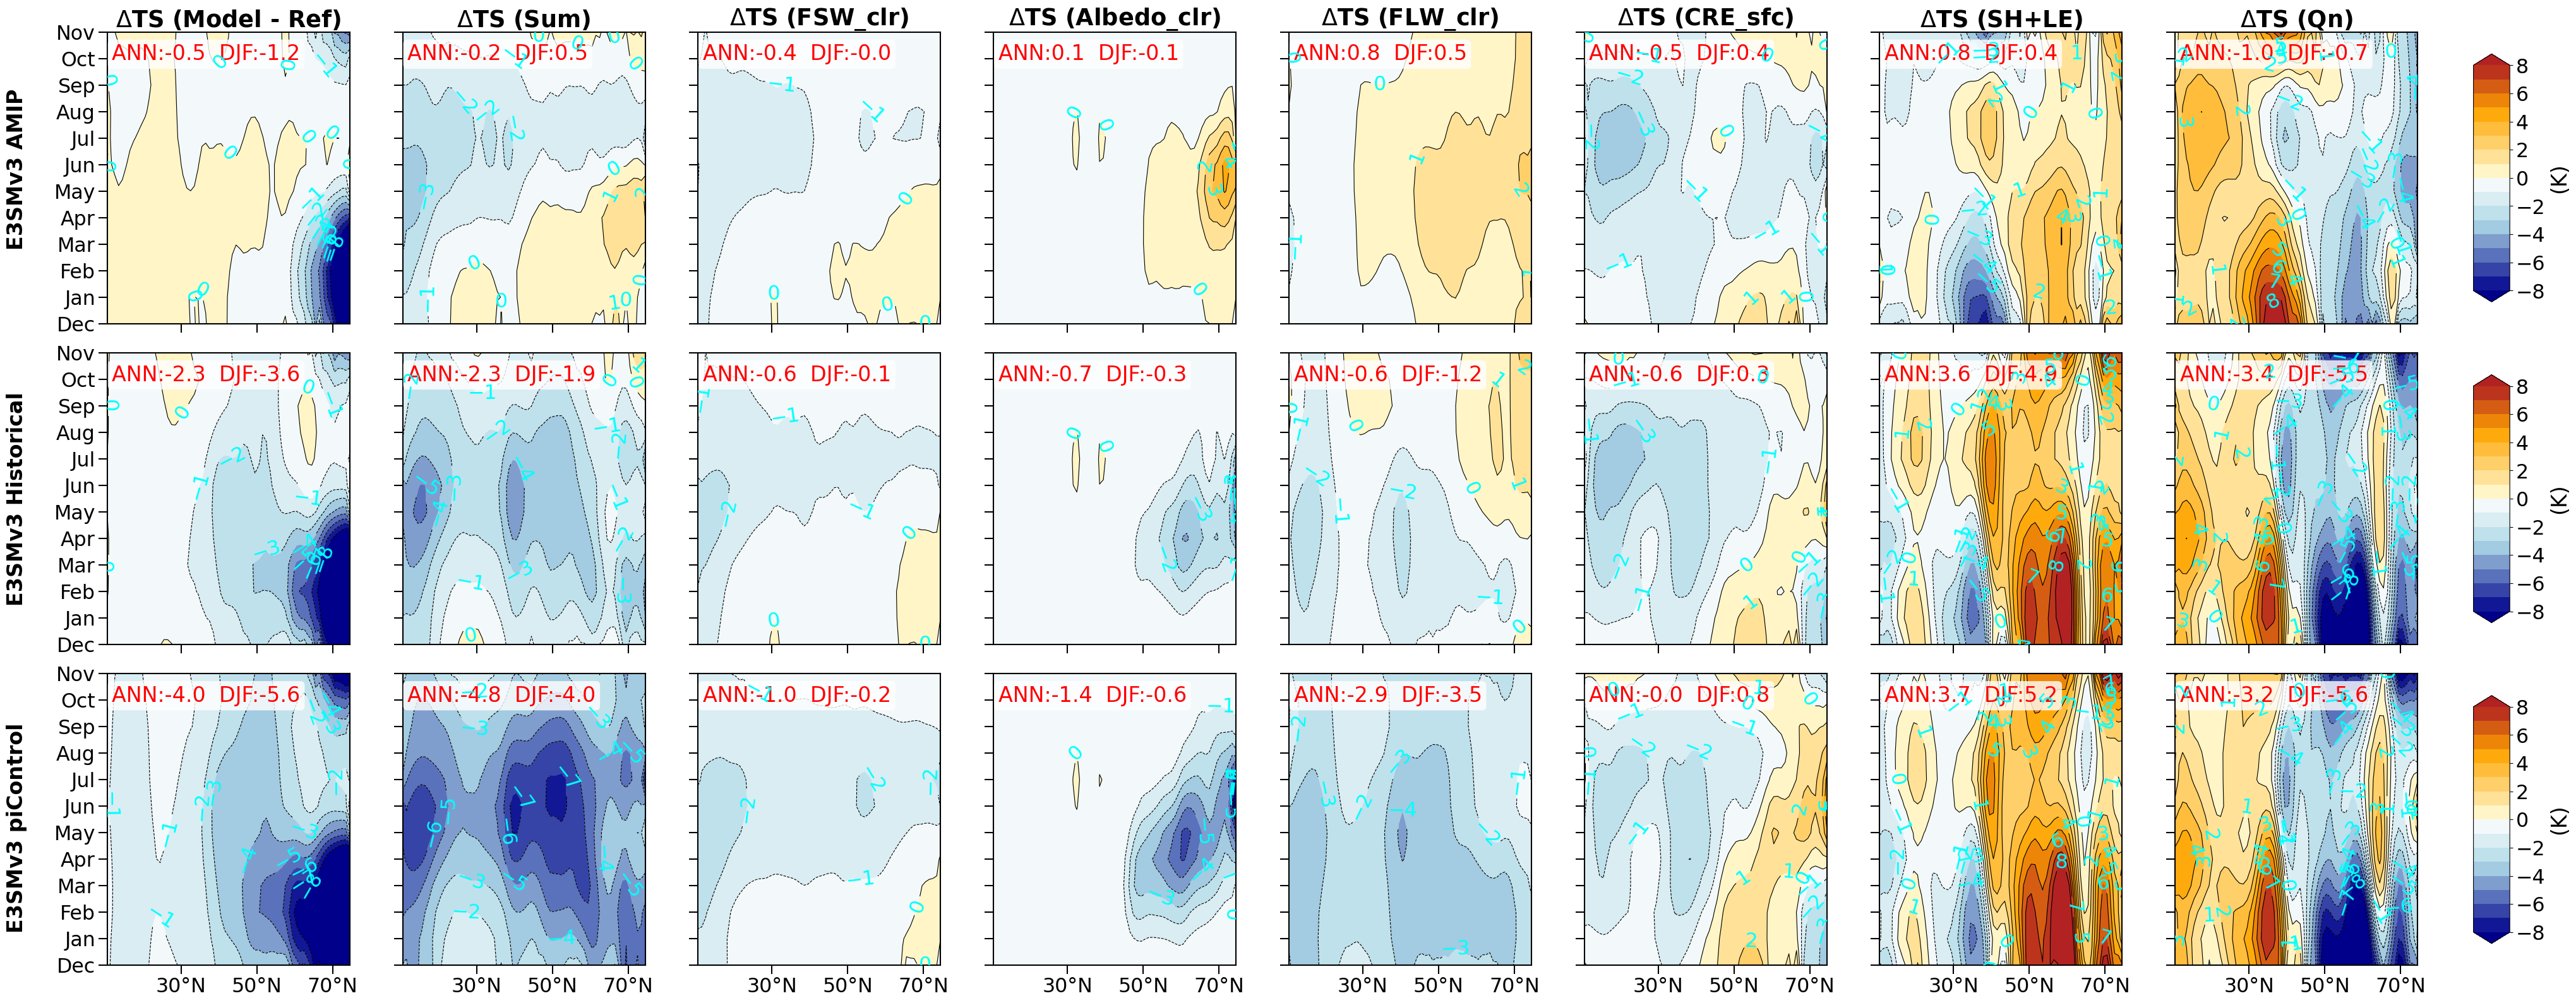

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_budget_best_obs_Atlantic_model_vs_obs_2001-2018.pdf


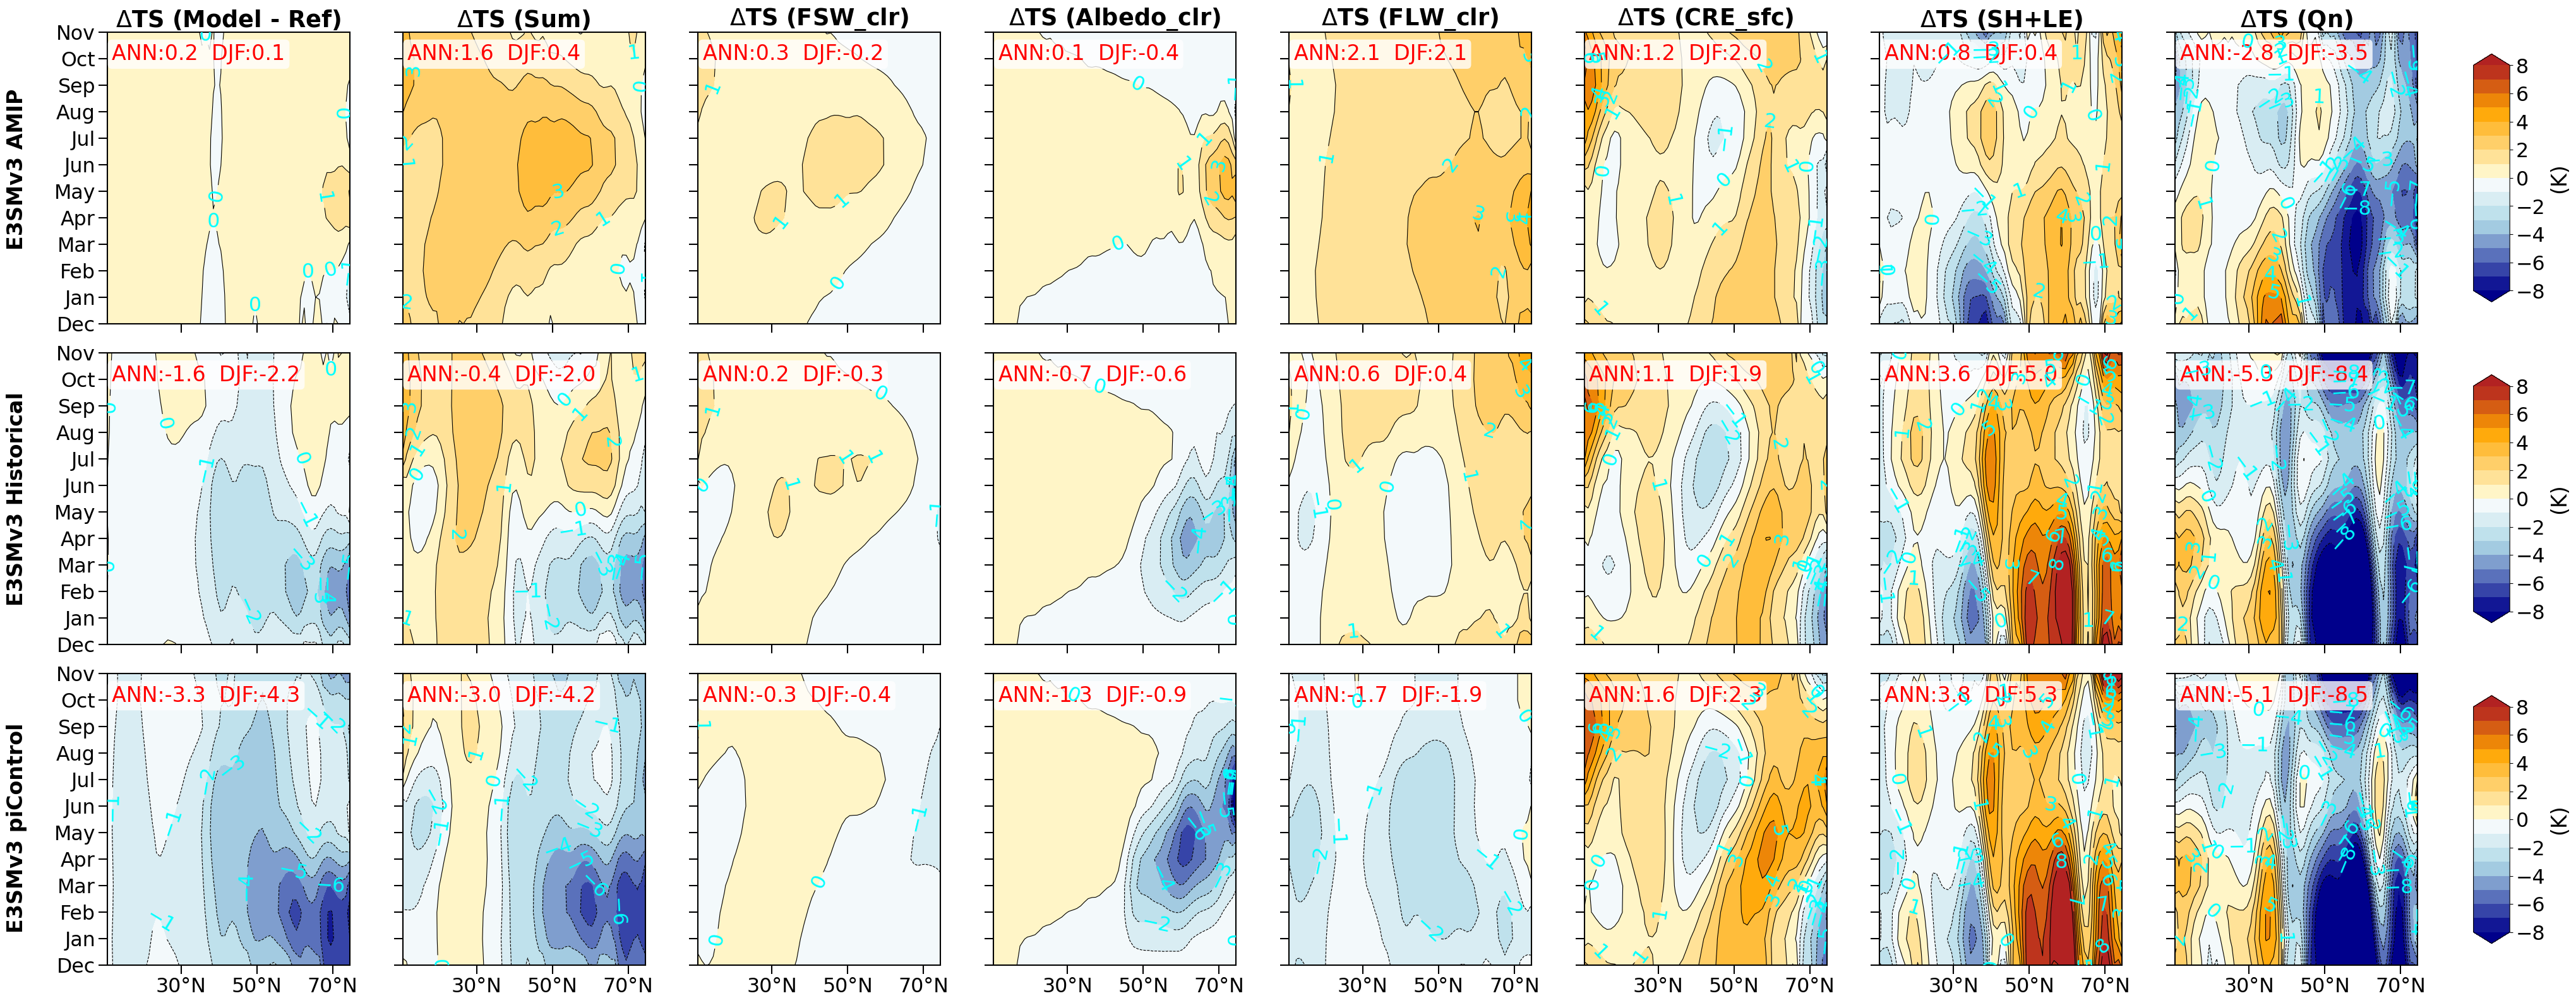

[ok] saved: /lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis/figure/Atlantic/fig_zonal_budget_all_merra_Atlantic_model_vs_obs_2001-2018.pdf


In [52]:
if __name__ == "__main__":
    # --- paths ---
    top_path  = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/energy_budge_analysis"
    data_path = f"{top_path}/data/climo"
    out_path  = f"{top_path}/diag_data"
    fig_path  = str(FIG_DIR_ROOT)

    # --- controls ---
    regnam     = "Atlantic"
    dtype      = "climo"
    plot_type  = "model_vs_obs"
    months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
    
    sfc_mask_ref   = "HadISST.analysis"     # must exist in RUN_CATALOG
    sfc_mask_kind  = "ocean"
    sfc_mask_var   = "TS"
    
    # --- echo metadata safely ---
    refexp = "HadISST.analysis"  # must exist in RUN_CATALOG
    run_info = RUN_CATALOG[refexp]
    try:
        ref_name = run_info.name
        ref_period = run_info.period
    except AttributeError:
        ref_name = run_info["name"]
        ref_period = run_info["period"]

    reg_info = REGION_CATALOG[regnam]
    try:
        (lat_min, lat_max) = reg_info.lat_range
        (lon_min, lon_max) = reg_info.lon_range
    except AttributeError:
        (lat_min, lat_max), (lon_min, lon_max) = reg_info

    print(f"reference data and period: {ref_name}, {ref_period}")
    print(f"processed region: {regnam}, lat=({lat_min},{lat_max}), lon=({lon_min},{lon_max})")

    out_dir = f"{out_path}/{regnam}"
    fig_dir = f"{fig_path}/{regnam}"
    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(fig_dir, exist_ok=True)

    # --- read regionalized datasets ---
    reader = ExpDataReader(
        data_dir=data_path,
        regnam=regnam,
        dtype=dtype,
        sfc_mask_ref=sfc_mask_ref,
        sfc_mask_var=sfc_mask_var,
        sfc_mask_kind=sfc_mask_kind,
        verbose=True,
    )
    run_catalog, exp_dict, surface_mask = reader.read()

    print("Loaded runs:")
    pprint.pprint(list(run_catalog.keys()))

    # models to plot (exclude the reference for model-vs-obs bias panels)
    model_list = [k for k in run_catalog if k != refexp]
    for exclude in [
        'MODIS.observation',
        "HadISST.analysis",
        'CERES_EBAF.observation',
        'ERA5.ensmn',
        'MERRA2.analysis',
        'ERA5.analysis',
        'v3.LR.piControl.hexagonal',
        '20250327.v3.SORRME3r3.piControl.alfred2.chrysalis',
    ]:
        if exclude in model_list:
            model_list.remove(exclude)

    # --- figure scaling (no seasons; single row of panels) ---
    budget_type = "best_obs" # or "all_merra"
    budget_vars  = list(Budget_CATALOG.keys())  # e.g., ['TS','ALBEDOC_SRF','ALBEDO_SRF']

    ncols = max(len(model_list), 1)
    base_w, base_h = 16.0, 4         # tuned for ~5 columns
    fcol = ncols / 5.0
    frow = len(budget_vars) / 5.0 
    fgw  = base_w * fcol
    fgh  = base_h * frow                # single row
    ws, hs = 0.05, 0.1
    fontz = 24
    # helper to sanitize periods used in filenames
    save_period = ref_period.replace("\u2010","-").replace("\u2011","-").replace("\u2012","-") \
                                .replace("\u2013","-").replace("\u2014","-").replace("\u2212","-")
     
    # --- loop over budget_type 
    for budget_type in ["best_obs", "all_merra"]: 
        plotter = ZonalBugetAnalysis(
            run_dict=run_catalog,
            df=exp_dict,
            lmsk=surface_mask,
            months=months,
            regnam=regnam,
            model_list=model_list,
            plot_type=plot_type,
            budget_type=budget_type,
            budget_vars=budget_vars,    # <— drives the derivation/plot columns
            term_specs=Budget_CATALOG, # optional: dict like {'TS_Qn': {'min':-5,'max':5,'nlev':21,'unit':'K'}, ...}
            fgw=fgw, fgh=fgh, ws=ws, hs=hs,
            region_catalog=REGION_CATALOG,
        )
        
        # expected filename produced by the class (so we can move/rename)
        # class builds: f"fig_zonalmean_{plot_type}_{ref_str}_{self.var}_{self.regnam}_{period}.pdf"
        expected_outname = f"fig_zonalbudget_{plot_type}_{budget_type}_{budget_vars[0]}_{regnam}_{save_period}.pdf"
        desired_savepath = os.path.join(
            fig_dir,
            f"fig_zonal_budget_{budget_type}_{regnam}_{plot_type}_{save_period}.pdf"
        )

        try:
            # class does not accept savepath/fontz; it saves into CWD
            produced = plotter.plot(show=True, fontz=fontz)  # returns outname
            # produced should equal expected_outname; move to desired path
            src = produced if isinstance(produced, str) else expected_outname
            if os.path.exists(src):
                shutil.move(src, desired_savepath)
                print(f"[ok] saved: {desired_savepath}")
            else:
                # fallback: try to locate any file that matches the class pattern
                candidates = [expected_outname]
                for cand in candidates:
                    if os.path.exists(cand):
                        shutil.move(cand, desired_savepath)
                        print(f"[ok] saved: {desired_savepath}")
                        break
                else:
                    print(f"[warn] expected output '{expected_outname}' not found; left in default location.")
        except Exception as e:
            print(f"[fail] {budget_type}: {e}")
